# HydroServer Exercise 3 - Rwanda: Query Metadata and Data from HydroServer using hydroserverpy

### **Overview**

This Jupyter Notebook demonstrates how to query time-series data and metadata from a datastream stored in HydroServer using the hydroserverpy Python package. The data are returned as a Pandas DataFrame, making them easy to manipulate, analyze, and visualize.

More detailed examples of how to use [hydroserverpy](https://pypi.org/project/hydroserverpy/) are available in HydroServer's documentation at:

* https://hydroserver2.github.io/hydroserver/user-guides/how-to/using-the-python-client.html
* https://www.hydroserver.org

### **Prerequisites**

You must have an account on the HydroServer Playground instance to run this notebook. If you haven't set up your user account yet, navigate to https://playground.hydroserver.org and follow the instructions to create a new user account.

### **References**

Code adapted by the Center for Geospatial Solutions from examples developed by the HydroServer development team, including Jeff Horsburgh, Ken Lippold, and Daniel Slaugh. The original materials are available in this [HydroShare resource](https://www.hydroshare.org/resource/136c2bc6512540d59ce707bbd9c93e8a/).


## 1. Getting Started

---

### **Install hydroserverpy**

For this workshop, we will use Google Colab to run the exercises. Before starting, run the code cell below to install the required version of the hydroserverpy package. For this exercise, we will connect to the HydroServer Playground instance at playground.hydroserver.org. The current version of hydroserverpy used for this training is [1.11.3.](https://pypi.org/project/hydroserverpy/)

In [2]:
!pip install hydroserverpy==1.11.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 1.8 MB/s eta 0:00:00


### **Import the Required Python Packages**

First, we import the Python packages needed for this exercise:

- **hydroserverpy** – Connects to HydroServer and allows us to query resources, metadata, and observations.
- **datetime** – Helps define and work with dates and times.
- **matplotlib** – Used to visualize the observations retrieved from HydroServer.
- **getpass** – Allows you to enter your HydroServer password securely without displaying it on the screen.

In [3]:
from hydroserverpy import HydroServer
from datetime import datetime
import matplotlib.pyplot as plt
from getpass import getpass

### **Set the Initial Parameters to Connect to HydroServer**

The first step in interacting with a HydroServer instance is to create a connection to that instance. For this example, we will use your username and password because we will create the Workspace in code.

**IMPORTANT: In the following code, change the email to match the HydroServer user account you created.**

In [4]:
# Set initial parameters to connect to HydroServer
hydroserver_host = 'https://playground.hydroserver.org'

# Change the email and password below to your HydroServer username and password
hydroserver_email = 'svicario@lincolninst.edu' #'user@youremail.com'
hydroserver_password = getpass('Enter your HydroServer password: ') #getpass('Enter your HydroServer password: ')

Enter your HydroServer password: ··········


### **Initialize HydroServer Connection**

Initialize the connection to HydroServer with the connection information specified above.

In [5]:
# Initialize HydroServer connection with credentials.
hs = HydroServer(
    host=hydroserver_host,
    email=hydroserver_email,
    password=hydroserver_password
)

print('\nSuccessfully connected to HydroServer!')


Successfully connected to HydroServer!


## 2. Querying Metadata from HydroServer

---

Querying metadata from HydroServer is pretty straightforward once you have a basic understanding of HydroServer's data model. W

e'll start with getting information about Workspaces. Generally, a Workspace is a container within which you organize monitoring sites (Things).

Each monitoring site can have any number of Datastreams. A Datastream is a time series of Observation values. There's other important metadata, but the important heirarchy is:

Workspace --> Thing --> Datastream --> Observations

### **Query Workspaces**

We'll start by getting a list of Workspaces I have access to. These are workspaces that I own, have been shared with me, or that are publicly available.

In [7]:
workspaces = hs.workspaces.list()

# Print the names of the first 5 workspaces that were returned:
print(f'\nList of workspaces I have access to:\n')
for workspace in workspaces.items[:5]:
    print(workspace.name)


List of workspaces I have access to:

Test Workspace
Test Workspace #2
Stream gauge register
Vincent
DRE


### **Query Workspaces You are Affiliated With**

Many of the workspaces on the Playground instance of HydroServer were set up for testing and aren't relevant to you. So, let's limit the query to return only workspaces with which you are affiliated (you either own them or you have been given access).

In [8]:
# Limit the list to workspaces I am affiliated with.
my_workspaces = hs.workspaces.list(is_associated=True)

print(f'\nList of workspaces I am affiliated with:\n')
for workspace in my_workspaces.items:
    print(workspace.name)


List of workspaces I am affiliated with:

Rwanda Training 2026 - Sara


### **Query a Workspace with a Specific Name**

To get a specific workspace by name, first retrieve your list of workspaces, then search the list for the workspace with the name you want.

IMPORTANT: Replace the workspace name below with the name of your own workspace.

In [9]:
workspace = [
    workspace
    for workspace in my_workspaces.items
    if workspace.name == "Rwanda Training 2026 - Sara"  # Change this name to your workspace name
][0]

workspace_id = workspace.uid

print(f"\nRetrieved workspace: {workspace.name}")
print(f"\nRetrieved workspace uid: {workspace_id}")


Retrieved workspace: Rwanda Training 2026 - Sara

Retrieved workspace uid: 01a062cb-7ae3-7dd6-a6d6-0ea739c93849


### **Query Monitoring Sites (Things)**

We can also query information about monitoring sites (Things) in the database. Similar to Workspaces, you can return all of the Things you own (regardless of Workspace) or you can limit the list of Things to a particular Workspace. The code below does both. The Workspace used here is the Workspace returned in the last step where we searched for a Workspace with a specific name.

In [10]:
# Limit the list to the Things in a particular workspace
workspace_things = workspace.things
for thing in workspace_things:
    print(thing.name)

Kanzenze Hydrological Station


### **Retrieve a Specific Monitoring Site (Thing) Using its Name**

Currently, to retrieve a specific Thing using its name, you need to return a list of Things that is known to include the one you want (e.g., the list of Things in a Workspace) and then iterate to find the Thing you want in the list.

If you know the UUID of a Thing, you can use it to retrieve that specific Thing. The code below first finds the Thing by its name and gets its UUID

**IMPORTANT**: If you want to search for a Thing with a different name, change the name of the Thing on the following block code.

In [12]:
thing = [
    thing
    for thing in workspace_things
    if thing.name == "Kanzenze Hydrological Station"  # Set the name of the thing you want to find
][0]

# Get a thing using its identifier
thing_id = thing.uid  # Get the ID for a thing

print(f"\nRetrieved thing: {thing.name}")


Retrieved thing: Kanzenze Hydrological Station


### **Query Attributes of a Monitoring Site (Thing)**

The metadata you get back from HydroServer is organized in Python objects that can easily be queried. The following code shows how to extract the attributes for the Thing object you just retrieved in the last step. If you know the UUID for a Thing, you can use it to get the metadata. UUIDs for Things are displayed on the landing page for that Monitoring Site (Thing) in the HydroServer Data Management App.

In [13]:
# Get attributes of a Thing
print(f'\nExtracting attributes of a Thing:\n')
print(f'Site name: {thing.name}')
print(f'Site description: {thing.description}')
print(f'Latitude: {thing.latitude}')
print(f'Longitude: {thing.longitude}')
print(f'Site type: {thing.site_type}')

# You can get the same information if you know the UUID for a Thing
#thing = hs.things.get(uid=thing.uid)  # Get the thing that goes with that ID
#print(f'\nExtracting attributes of a Thing using its ID:\n')
#print(f'Site name: {thing.name}')
#print(f'Site description: {thing.description}')
#print(f'Latitude: {thing.latitude}')
#print(f'Longitude: {thing.longitude}')
#print(f'Site type: {thing.site_type}')


Extracting attributes of a Thing:

Site name: Kanzenze Hydrological Station
Site description: Hydrological monitoring station on the Nyabarongo River at Kanzenze, Rwanda.
Latitude: -2.0613
Longitude: 30.0877
Site type: Stream


### **Retrieve a Datastream Using Its Name**

To retrieve a specific **Datastream** by name, you can search through the list of datastreams associated with a **Monitoring Site (Thing)**.

The code below finds the Datastream by its **name** and gets its **UUID**.

**IMPORTANT:** To search for a different Datastream, change the Datastream name in the code below.

In [17]:
# Name of the datastream
datastream_name = "Stage - Real-time - Kanzenze Hydrological Station"

# Get the datastream by name
ds = next(
    ds for ds in thing.datastreams
    if ds.name == datastream_name
)

# Get its identifier
ds_id = ds.uid

print("Datastream ID:", ds_id)
print("Datastream name:", ds.name)

Datastream ID: 01a066bf-f2e7-770e-8d87-8a780e8fb344
Datastream name: Stage - Real-time - Kanzenze Hydrological Station


### **Query Attributes of a Datastream**

The metadata you get back from HydroServer is organized in Python objects that can easily be queried. The following code shows how to extract attributes from the **Datastream object** you just retrieved in the previous step. If you know the **UUID of a datastream**, you can use it to retrieve its metadata directly from HydroServer.

In [18]:
# Get the identifier for a datastream
ds_id = thing.datastreams[0].uid

# Retrieve a datastream object containing the metadata for the datastream
print(f"\nRetrieving information for datastream {ds_id}\n")
ds = hs.datastreams.get(ds_id)
print(f"Datastream name: {ds.name}")
print(f"Observed property name: {ds.observed_property.name}")
print(f"Processing level: {ds.processing_level.definition}")
print(f"Description: {ds.description}")
ds.units.abbreviation


Retrieving information for datastream 01a062cb-a69a-7ede-bc2a-4aecd2db13a2

Datastream name: Stage - Historical - Kanzenze Hydrological Station
Observed property name: Stage
Processing level: Raw Data
Description: Historical stage observations at Kanzenze Hydrological Station


AttributeError: 'Datastream' object has no attribute 'units'

## 3. Querying Observation Values from a Datastream in HydroServer

---

Now that we have the UUID for the Datastream, we can retreive the Observation values using ```get_observations()```. You have three options for controlling what is returned (examples are shown below). The function returns an "ObservationCollection" object that contains a Pandas DataFrame along with the metadata for the Datastream.

In the ```get_observations()``` function call, the ```fetch_all=True``` argument will retrieve all of the Observations for the Datastream. Otherwise, the response is limited to 100,000 observations.  Or, you can get Observations within a specific time range by passing a beginning and ending date for the query.

In [19]:
# This function call will be limited to 100,000 Observations
# obs_df = ds.get_observations().dataframe

# This function call will retrieve all Observations for the Datastream
# obs_df = datastream.get_observations(fetch_all=True).dataframe

# This function call will get the Observations between two timestamps
obs_df = ds.get_observations(
    phenomenon_time_min=datetime(year=2025, month=12, day=31),
    phenomenon_time_max=datetime(year=2026, month=8, day=13)
).dataframe

print(f'\nRetrieved {len(obs_df)} Observations for {ds.name} datastream')


Retrieved 0 Observations for Stage - Historical - Kanzenze Hydrological Station datastream


### Make a Quick Plot of the Datastream

We've got the Observation values, now we can generate a quick plot using Matplotlib. In the Pandas DataFrame that is returned, the timestamps are stored in a column called "phenomenon_time", and the Observation values are stored in a column called "result". Those are the columns we need for the plot.

The LRO uses -9999 as a NoData value to indicate instances where there should be a value, but for some reason is not. Our plot won't be that useful unless we filter those -9999 values out first.

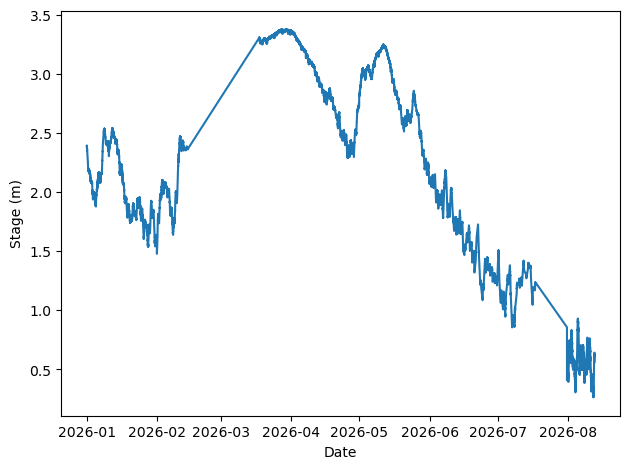

In [ ]:
# Filter out any nodata values in the dataframe that is returned
obs_df_sub = obs_df[(obs_df['result'] != -9999)]

# Make a qick plot of the Datastream using matplotlib
plt.plot(obs_df_sub['phenomenon_time'], obs_df_sub['result'], linestyle='-')
plt.xlabel('Date')
# Use the observed property name and unit from the Datastream metadata to label the y-axis
plt.ylabel(f'{ds.observed_property.name} ({ds.unit.symbol})')
plt.tight_layout()
plt.show()

## **Summary**

Now you know the general patterns for how to query HydroServer using hydroserverpy to return metadata and observations. Once you've got them in your Python environment, you can use all of the available tools in Pandas, Matplotlib, and other libraries to manipulate and visualize the data.

### **Additional Examples**

The code below shows how to retrieve different **attributes** containing the metadata of the **monitoring site**.

In [ ]:
# Basic information
print(f"UID: {thing.uid}")
print(f"Name: {thing.name}")
print(f"Description: {thing.description}")

# Monitoring site information
print(f"Sampling feature type: {thing.sampling_feature_type}")
print(f"Sampling feature code: {thing.sampling_feature_code}")
print(f"Site type: {thing.site_type}")

# Location
print(f"Latitude: {thing.latitude}")
print(f"Longitude: {thing.longitude}")
print(f"Elevation: {thing.elevation_m}")
print(f"Elevation datum: {thing.elevation_datum}")

# Administrative location
print(f"Administrative area 1: {thing.admin_area_1}")
print(f"Administrative area 2: {thing.admin_area_2}")
print(f"Country: {thing.country}")

# Data information
print(f"Data disclaimer: {thing.data_disclaimer}")

# Workspace
print(f"Workspace ID: {thing.workspace_id}")
print(f"Workspace name: {thing.workspace.name}")

# Visibility
print(f"Private: {thing.is_private}")

# Tags
print(f"Tags: {thing.tags}")

# Datastreams
print(f"Datastreams: {thing.datastreams}")

The code below shows how to retrieve different **attributes** containing the metadata of the **datastream**.

In [21]:
# Basic information
print(f"UID: {ds.uid}")
print(f"Name: {ds.name}")
print(f"Description: {ds.description}")

# Observed property
print(f"Observed property name: {ds.observed_property.name}")
print(f"Observed property definition: {ds.observed_property.definition}")
print(f"Observed property description: {ds.observed_property.description}")
print(f"Observed property code: {ds.observed_property.code}")

# Processing level
print(f"Processing level code: {ds.processing_level.code}")
print(f"Processing level definition: {ds.processing_level.definition}")
print(f"Processing level explanation: {ds.processing_level.explanation}")

# Unit
print(f"Unit name: {ds.unit.name}")
print(f"Unit symbol: {ds.unit.symbol}")
print(f"Unit definition: {ds.unit.definition}")
print(f"Unit type: {ds.unit.unit_type}")

# Sensor
print(f"Sensor name: {ds.sensor.name}")
print(f"Sensor description: {ds.sensor.description}")

# Monitoring site
print(f"Monitoring site: {ds.thing.name}")

# Observation metadata
print(f"Observation type: {ds.observation_type}")
print(f"Sampled medium: {ds.sampled_medium}")
print(f"No-data value: {ds.no_data_value}")
print(f"Aggregation statistic: {ds.aggregation_statistic}")

# Time information
print(f"Time aggregation interval: {ds.time_aggregation_interval}")
print(f"Time aggregation interval unit: {ds.time_aggregation_interval_unit}")
print(f"Intended time spacing: {ds.intended_time_spacing}")
print(f"Intended time spacing unit: {ds.intended_time_spacing_unit}")

# Status
print(f"Status: {ds.status}")
print(f"Result type: {ds.result_type}")
print(f"Value count: {ds.value_count}")

# Observation period
print(f"Phenomenon begin time: {ds.phenomenon_begin_time}")
print(f"Phenomenon end time: {ds.phenomenon_end_time}")

# Result period
print(f"Result begin time: {ds.result_begin_time}")
print(f"Result end time: {ds.result_end_time}")

# Visibility
print(f"Private: {ds.is_private}")
print(f"Visible: {ds.is_visible}")

UID: 01a062cb-a69a-7ede-bc2a-4aecd2db13a2
Name: Stage - Historical - Kanzenze Hydrological Station
Description: Historical stage observations at Kanzenze Hydrological Station
Observed property name: Stage
Observed property definition: Stage
Observed property description: Stage is the height of the water surface at a monitoring location relative to a reference level.
Observed property code: Stage
Processing level code: Raw
Processing level definition: Raw Data
Processing level explanation: Data that have not been processed or quality controlled.
Unit name: Meter
Unit symbol: m
Unit definition: Unit for water stage
Unit type: Length
Sensor name: Kanzenze Historical Stage Observations
Sensor description: Historical stage observations recorded at the Kanzenze hydrological station.
Monitoring site: Kanzenze Hydrological Station
Observation type: Field Observation
Sampled medium: Surface Water
No-data value: -9999.0
Aggregation statistic: Continuous
Time aggregation interval: 0.0
Time aggreg